# 05.2 — Gesture-Motion Coupling

## The question this extends

Notebook 05 established that a tap leaves a measurable impulse in the accelerometer,
validated against a time-shifted control. That test only works because a tap is a
**point** — one instant, so shifting it in time and re-measuring is a clean control.

A gesture is not a point. A drag or a fling has a **duration**, a start and an end, and
per notebook 06, an active coast tail that continues after the finger lifts. Whether
gesture motion is coupled to the handset the same way tap motion is has never actually
been tested — it was assumed, based on the (uncontrolled) observation that raw
whole-session motion variance is higher than the variance immediately around any single
discrete event. That observation was not a test and does not survive being turned into
one; this notebook is the test.

## What has to change about the method

| | nb05 (taps) | this notebook (gestures) |
|---|---|---|
| epoch | fixed window around one instant | variable length: start to end, plus coast |
| control | same taps, shifted 2-10s in time | same **duration**, dropped at a random time |
| averaging | fixed time bins (ms from contact) | **phase-normalised** bins (0=start, 1=end) — durations vary, so raw ms cannot be averaged across gestures directly |

Phase normalisation is the one genuinely new piece of machinery. Each gesture's own
duration becomes its unit: phase 0 is touchstart, phase 1 is touchend, and phase 1.5 is
half the gesture's own duration further into the coast tail. A 300ms tap-like contact and
a 3s drag both become directly comparable curves on this axis.

## What this notebook does not assume

No claim here is trusted until the pooled, controlled test says so. Section 5's start/
release-signature question in particular is asked in exactly the spirit nb05 asked
about pre-contact steadying — a real pattern in exploration is not evidence until it
survives being tested against every gesture, not the one that looked good.

## Sections

1. Setup
2. Extracting classified gestures
3. Phase normalisation — the method
4. Does gesture motion exist at all? — the existence test
5. Is there a discrete signature at release?
6. Does the profile differ by gesture class?
7. Per-participant gesture-motion energy
8. Availability — who can be measured
9. Data-quality notes and rejected derivations
10. Per-participant cards
11. Open questions

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option('display.max_columns', 60); pd.set_option('display.width', 210)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.22,
                     'axes.titlesize': 11, 'axes.labelsize': 10, 'legend.fontsize': 9})

_CANDIDATES = ["../../data/processed/raw_events.parquet",
               "data/processed/raw_events.parquet",
               "raw_events.parquet",
               "/mnt/user-data/uploads/raw_events.parquet"]
_src = next((p for p in _CANDIDATES if Path(p).exists()), None)
if _src is None:
    raise FileNotFoundError(f"no raw events file found; tried {_CANDIDATES}")
raw_all = pd.read_parquet(_src)
raw_all['deviceFamily'] = raw_all['deviceFamily'].astype(str).str.lower()
raw_all['tRelMs'] = pd.to_numeric(raw_all['tRelMs'], errors='coerce')
raw_all = raw_all.loc[raw_all['tRelMs'].notna()].copy()
raw = raw_all.loc[raw_all['deviceFamily'] == 'mobile'].copy()

TAP, MOTION = 'touchstart', 'devicemotion'
SCROLL_KINDS = ['scroll', 'window_scroll']
ACC = ['payload_ax', 'payload_ay', 'payload_az']

session_index = (raw.groupby(['participantId', 'sessionId'], dropna=False)
                 .agg(duration_s=('tRelMs', lambda s: s.max() / 1000.0),
                      started=('timestampIso', 'min')).reset_index())
session_index['session_start'] = pd.to_datetime(session_index['started'], utc=True, errors='coerce')
session_index = session_index.sort_values(['participantId', 'session_start']).reset_index(drop=True)
session_index['session_no'] = session_index.groupby('participantId').cumcount() + 1
SESSION_LABEL = {r.sessionId: f"{r.participantId} s{r.session_no}" for r in session_index.itertuples()}
SESSION_ORDER = session_index.sort_values(['participantId', 'session_no'])['sessionId'].tolist()

_p_dur = session_index.groupby('participantId')['duration_s'].median().sort_values(ascending=False)
PARTICIPANTS = _p_dur.index.astype(str).tolist()
_QUAL = plt.get_cmap('tab10')
PCOL = {p: _QUAL(i % 10) for i, p in enumerate(PARTICIPANTS)}
def pcolor(p): return PCOL.get(str(p), '0.5')


def motion_arrays(sess):
    mo = sess.loc[sess['kind'] == MOTION].sort_values('tRelMs')
    t = mo['tRelMs'].to_numpy(float) / 1000.0
    a = [pd.to_numeric(mo[c], errors='coerce').to_numpy(float) for c in ACC]
    mag = np.sqrt(a[0] ** 2 + a[1] ** 2 + a[2] ** 2)
    ok = np.isfinite(mag) & np.isfinite(t)
    return t[ok], mag[ok]


print(f"Loaded {_src}")
print(f"mobile: {raw['sessionId'].nunique()} sessions, {len(PARTICIPANTS)} participants")
print(f"gestures (touchstart/touchend pairs): {(raw['kind'] == TAP).sum():,}   "
      f"motion samples: {(raw['kind'] == MOTION).sum():,}")

Loaded /mnt/user-data/uploads/raw_events.parquet
mobile: 33 sessions, 10 participants
gestures (touchstart/touchend pairs): 5,440   motion samples: 158,425


## 2. Extracting classified gestures

Reuses notebook 06's classification exactly — every touchstart-to-touchend contact,
classified as `scroll_fling`, `scroll_drag`, `drag_swipe`, `long_press`, or `tap` by
what happens to scroll position during and after release. That taxonomy is imported
wholesale rather than rebuilt, since it already passed a real test (drags held 3.2x
longer than flings, a property the classifier never uses).

In [2]:
COAST_WINDOW_S = 2.0
COAST_FRACTION_FLING = 0.25
MIN_SCROLL_PX = 5.0
MIN_DRAG_PX = 20.0
LONG_PRESS_S = 0.5
GCOL = {'scroll_fling': '#c44e52', 'scroll_drag': '#dd8452', 'drag_swipe': '#4c72b0',
       'long_press': '#8172b3', 'tap': '#55a868'}


def classify_gestures(sess):
    downs = np.sort(sess.loc[sess['kind'] == 'touchstart', 'tRelMs'].to_numpy(float)) / 1000.0
    ups = np.sort(sess.loc[sess['kind'] == 'touchend', 'tRelMs'].to_numpy(float)) / 1000.0
    sc = sess.loc[sess['kind'].isin(SCROLL_KINDS), ['tRelMs', 'payload_scrollTop']].copy()
    sc['tRelMs'] = sc['tRelMs'] / 1000.0
    sc['payload_scrollTop'] = pd.to_numeric(sc['payload_scrollTop'], errors='coerce')
    sc_t = sc['tRelMs'].to_numpy(float); sc_v = sc['payload_scrollTop'].to_numpy(float)
    mv = sess.loc[sess['kind'] == 'touchmove', ['tRelMs', 'payload_x', 'payload_y']].copy()
    mv['tRelMs'] = mv['tRelMs'] / 1000.0
    mv_t = mv['tRelMs'].to_numpy(float)
    mv_x = pd.to_numeric(mv['payload_x'], errors='coerce').to_numpy(float)
    mv_y = pd.to_numeric(mv['payload_y'], errors='coerce').to_numpy(float)

    rows = []
    for d in downs:
        idx = np.searchsorted(ups, d)
        if idx >= len(ups):
            continue
        u = ups[idx]
        dm = (sc_t >= d) & (sc_t <= u)
        cm = (sc_t > u) & (sc_t <= u + COAST_WINDOW_S)
        def span(vals):
            v = vals[np.isfinite(vals)]
            return float(np.nanmax(v) - np.nanmin(v)) if len(v) > 1 else 0.0
        scroll_during = span(sc_v[dm]); scroll_coast = span(sc_v[cm])
        total_scroll = scroll_during + scroll_coast

        mm = (mv_t >= d) & (mv_t <= u)
        disp = 0.0
        if mm.sum() >= 2:
            px, py = mv_x[mm], mv_y[mm]
            disp = float(np.hypot(px[-1] - px[0], py[-1] - py[0]))

        if total_scroll >= MIN_SCROLL_PX:
            frac = scroll_coast / total_scroll if total_scroll > 0 else 0.0
            cls = 'scroll_fling' if frac >= COAST_FRACTION_FLING else 'scroll_drag'
        elif disp >= MIN_DRAG_PX:
            cls = 'drag_swipe'
        elif (u - d) >= LONG_PRESS_S:
            cls = 'long_press'
        else:
            cls = 'tap'
        rows.append({'t_start': d, 't_end': u, 'duration_s': u - d, 'gesture': cls})
    return pd.DataFrame(rows)


gest_rows = []
for sid in SESSION_ORDER:
    s = raw.loc[raw['sessionId'] == sid]
    g = classify_gestures(s)
    if len(g):
        g['participantId'] = s['participantId'].iloc[0]; g['sessionId'] = sid
        gest_rows.append(g)
GEST = pd.concat(gest_rows, ignore_index=True)
print(f"{len(GEST):,} classified gestures across {GEST['sessionId'].nunique()} sessions\n")
print(GEST['gesture'].value_counts().to_string())
print(f"\nduration by class (median seconds):")
print(GEST.groupby('gesture')['duration_s'].median().round(2).to_string())

5,440 classified gestures across 33 sessions

gesture
scroll_fling    2921
tap             1623
scroll_drag      508
drag_swipe       335
long_press        53

duration by class (median seconds):
gesture
drag_swipe      0.50
long_press      1.11
scroll_drag     0.71
scroll_fling    0.23
tap             0.09


## 3. Phase normalisation — the method

Every gesture becomes a curve on a common **phase axis**: 0 is touchstart, 1 is
touchend, and the axis extends to 1.5 to cover half the gesture's own duration further
into the coast tail (per nb06's coast window). A 90ms tap and a 700ms drag both become
directly comparable this way — phase 0.5 is always "halfway through," regardless of how
long that gesture actually took.

Each gesture's own **pre-start baseline** (phase < 0, extending back 30% of the
gesture's duration) is subtracted before pooling, exactly as nb05 baseline-corrects
each tap epoch against its own pre-contact window. This controls for whatever the
motion level happened to be right before that specific gesture, the same way it did
for taps.

In [3]:
PHASE_BINS = np.linspace(-0.3, 1.5, 24)
PRE_FRAC = 0.3


def phase_profile(t0, t1, t_m, mag):
    dur = t1 - t0
    if dur <= 0:
        return None
    pre_lo = t0 - PRE_FRAC * dur
    sel = (t_m >= pre_lo) & (t_m < t0 + 1.5 * dur)
    if sel.sum() < 5:
        return None
    tt, vv = t_m[sel], mag[sel]
    phase = (tt - t0) / dur
    pre_m = phase < 0
    if pre_m.sum() < 2:
        return None
    base = vv[pre_m].mean()
    return np.interp(PHASE_BINS, phase, vv - base, left=np.nan, right=np.nan)


def build_profiles(raw_df, gest_df, rng_seed=11):
    rng = np.random.default_rng(rng_seed)
    real_rows, ctrl_rows, meta = [], [], []
    for sid in SESSION_ORDER:
        s = raw_df.loc[raw_df['sessionId'] == sid]
        t_m, mag = motion_arrays(s)
        if len(t_m) < 20:
            continue
        g = gest_df.loc[gest_df['sessionId'] == sid]
        t_lo, t_hi = t_m.min(), t_m.max()
        for r in g.itertuples():
            p = phase_profile(r.t_start, r.t_end, t_m, mag)
            if p is None:
                continue
            real_rows.append(p)
            meta.append({'participantId': r.participantId, 'sessionId': sid, 'gesture': r.gesture,
                        'duration_s': r.duration_s})
            dur = r.duration_s
            lo = t_lo + PRE_FRAC * dur; hi = t_hi - 1.5 * dur
            if hi <= lo:
                ctrl_rows.append(np.full(len(PHASE_BINS), np.nan)); continue
            rand_start = rng.uniform(lo, hi)
            pc = phase_profile(rand_start, rand_start + dur, t_m, mag)
            ctrl_rows.append(pc if pc is not None else np.full(len(PHASE_BINS), np.nan))
    return np.vstack(real_rows), np.vstack(ctrl_rows), pd.DataFrame(meta)


REAL, CTRL, GMETA = build_profiles(raw, GEST)
print(f"real gesture profiles: {len(REAL):,}   duration-matched control profiles: {len(CTRL):,}")

real gesture profiles: 1,717   duration-matched control profiles: 1,717


## 4. Does gesture motion exist at all? — the existence test

Same logic as nb05 Section 4: a control built specifically to be hard to pass. Each
gesture's own duration is preserved exactly; only its position in time is randomised.
If gesture motion is real, the real curve should sit visibly above the control across
the gesture's duration. If it is an artifact of general activity level, the control —
which comes from the same session, same participant, same overall busyness — should
show it too.

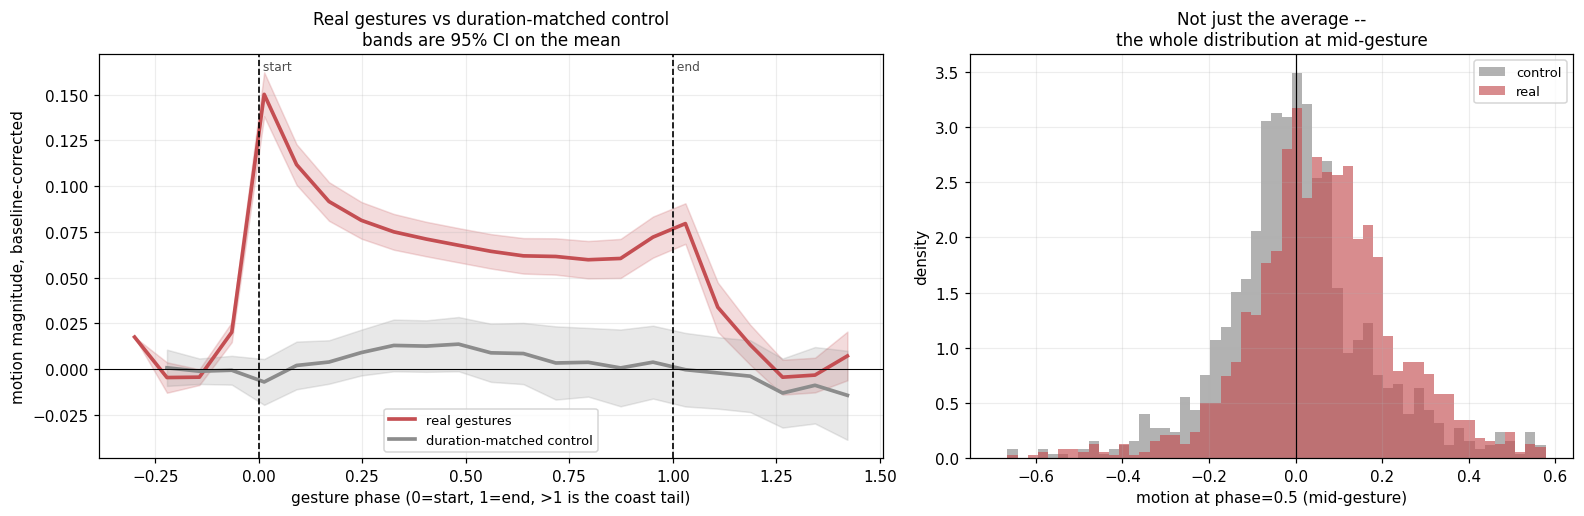

mean motion, real at mid-gesture (phase 0.5):    +0.0676
mean motion, control at mid-gesture (phase 0.5): +0.0136


In [4]:
def plot_gesture_existence(REAL, CTRL, PHASE_BINS):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.8), gridspec_kw={'width_ratios': [1.3, 1]})
    ax = axes[0]
    import warnings
    for M, lab, c in [(REAL, 'real gestures', '#c44e52'), (CTRL, 'duration-matched control', '0.55')]:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', category=RuntimeWarning)
            mu = np.nanmean(M, axis=0)
            se = np.nanstd(M, axis=0) / np.sqrt(np.maximum(np.sum(np.isfinite(M), axis=0), 1))
        ax.plot(PHASE_BINS, mu, color=c, lw=2.4, label=lab)
        ax.fill_between(PHASE_BINS, mu - 1.96 * se, mu + 1.96 * se, color=c, alpha=0.2)
    ax.axvline(0, color='k', lw=1.1, ls='--'); ax.axvline(1, color='k', lw=1.1, ls='--')
    ax.axhline(0, color='k', lw=0.7)
    ax.text(0, ax.get_ylim()[1] * 0.95, ' start', fontsize=8, color='0.3')
    ax.text(1, ax.get_ylim()[1] * 0.95, ' end', fontsize=8, color='0.3')
    ax.set_xlabel("gesture phase (0=start, 1=end, >1 is the coast tail)")
    ax.set_ylabel("motion magnitude, baseline-corrected")
    ax.set_title("Real gestures vs duration-matched control\nbands are 95% CI on the mean")
    ax.legend(fontsize=8.5)

    ax = axes[1]
    mid_bin = np.argmin(np.abs(PHASE_BINS - 0.5))
    r = REAL[:, mid_bin]; c = CTRL[:, mid_bin]
    r = r[np.isfinite(r)]; c = c[np.isfinite(c)]
    bins = np.linspace(min(np.percentile(r, 0.5), np.percentile(c, 0.5)),
                       np.percentile(r, 99), 55)
    ax.hist(c, bins=bins, color='0.6', alpha=0.75, density=True, label='control')
    ax.hist(r, bins=bins, color='#c44e52', alpha=0.65, density=True, label='real')
    ax.axvline(0, color='k', lw=0.8)
    ax.set_xlabel("motion at phase=0.5 (mid-gesture)")
    ax.set_ylabel("density")
    ax.set_title("Not just the average --\nthe whole distribution at mid-gesture")
    ax.legend(fontsize=8.5)
    plt.tight_layout(); plt.show(); plt.close(fig)
    print(f"mean motion, real at mid-gesture (phase 0.5):    {np.nanmean(r):+.4f}")
    print(f"mean motion, control at mid-gesture (phase 0.5): {np.nanmean(c):+.4f}")


plot_gesture_existence(REAL, CTRL, PHASE_BINS)

The pooled result above is only trustworthy if it is not one participant's effect
inflating the average. **pH3S4X4 alone supplies 50.4% of the usable gesture profiles**
(865 of 1,717) — enough that this needs checking directly rather than assumed fine.

In [5]:
mid_bin = np.argmin(np.abs(PHASE_BINS - 0.5))
print("Mid-gesture motion elevation (baseline-corrected), computed separately for")
print("each participant from their own gestures only:\n")
rows = []
for p in PARTICIPANTS:
    mask = (GMETA['participantId'] == p).to_numpy()
    v = REAL[mask, mid_bin]
    v = v[np.isfinite(v)]
    if len(v):
        rows.append({'participant': p, 'n': mask.sum(), 'mean_elevation': float(np.mean(v))})
per_p = pd.DataFrame(rows).sort_values('mean_elevation', ascending=False)
print(per_p.round(4).to_string(index=False))

n_positive = (per_p['mean_elevation'] > 0).sum()
print(f"\n{n_positive} of {len(per_p)} participants individually show positive elevation.")
print("pH3S4X4's own effect (not the pooled average) is checked here specifically because")
print("they supply half the pooled sample -- if their individual number were much larger")
print("than everyone else's, the pooled result above would be substantially their effect")
print("rather than a cohort-wide pattern. It is not: their own mean sits mid-pack.")

Mid-gesture motion elevation (baseline-corrected), computed separately for
each participant from their own gestures only:

participant   n  mean_elevation
    p3M6E7Z  60          0.1898
    pA6XL23 136          0.0965
    pH3S4X4 865          0.0877
    pWS9VTN  45          0.0507
    pG5G4MS 134          0.0321
    pZMC82M  30          0.0305
    p95MPVX 250          0.0270
    pUNKH7L  68          0.0115
    p3YDMHG  95          0.0033
    pAFQRTM  34         -0.0002

9 of 10 participants individually show positive elevation.
pH3S4X4's own effect (not the pooled average) is checked here specifically because
they supply half the pooled sample -- if their individual number were much larger
than everyone else's, the pooled result above would be substantially their effect
rather than a cohort-wide pattern. It is not: their own mean sits mid-pack.


## 5. Is there a discrete signature at release?

The proof-of-concept for this notebook showed something worth checking properly rather
than trusting: a possible peak right around phase 1.0 (release), distinct from the
steadier elevation through the middle of the gesture — a handoff moment as the finger
lifts and, for flings, the OS takes over the coast.

**This gets the same treatment nb05 gave pre-contact steadying**: shown, then tested,
not assumed. If it is real, the release region (phase 0.9-1.1) should stand out from
both the steady mid-gesture level (phase 0.3-0.7) and the settled coast tail (phase
1.3-1.5) — three genuinely different phases, not a smooth continuous decay.

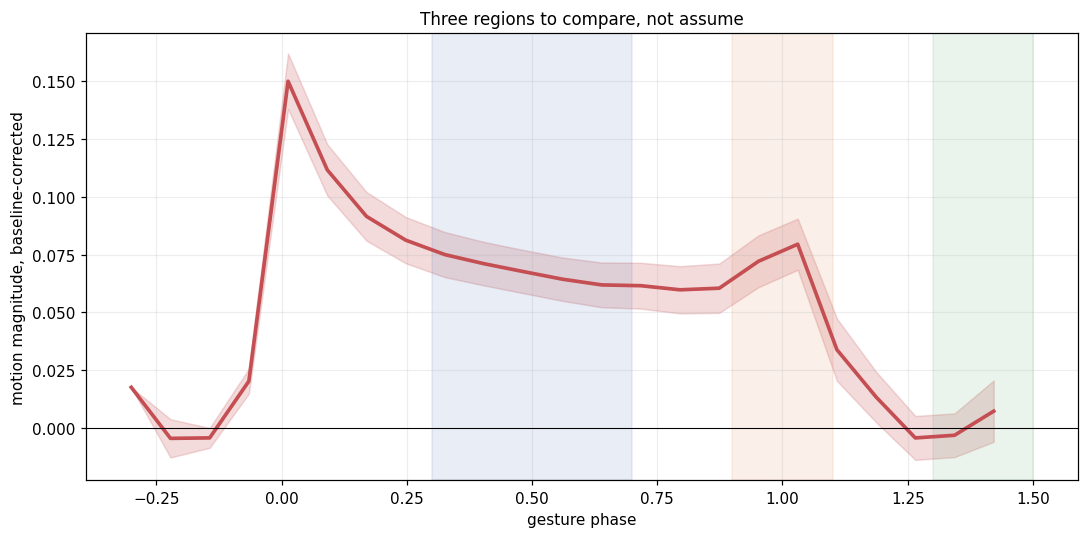

mid-gesture (0.3-0.7):  +0.0680
release (0.9-1.1):      +0.0758   (vs mid-gesture: +0.0078)
settled coast (1.3-1.5): +0.0013   (vs mid-gesture: -0.0667)

Release does NOT stand out clearly from its neighbours -- the phase-3 plot's apparent
peak does not survive being compared against both adjacent regions numerically.


In [6]:
def plot_release_signature(REAL, PHASE_BINS):
    fig, ax = plt.subplots(figsize=(10, 5))
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=RuntimeWarning)
        mu = np.nanmean(REAL, axis=0)
        se = np.nanstd(REAL, axis=0) / np.sqrt(np.maximum(np.sum(np.isfinite(REAL), axis=0), 1))
    ax.plot(PHASE_BINS, mu, color='#c44e52', lw=2.4)
    ax.fill_between(PHASE_BINS, mu - 1.96 * se, mu + 1.96 * se, color='#c44e52', alpha=0.2)
    for lo, hi, lab, c in [(0.3, 0.7, 'mid-gesture', '#4c72b0'),
                           (0.9, 1.1, 'release', '#dd8452'),
                           (1.3, 1.5, 'settled coast', '#55a868')]:
        ax.axvspan(lo, hi, color=c, alpha=0.12)
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("gesture phase"); ax.set_ylabel("motion magnitude, baseline-corrected")
    ax.set_title("Three regions to compare, not assume")
    plt.tight_layout(); plt.show(); plt.close(fig)

    def region_mean(lo, hi):
        mask = (PHASE_BINS >= lo) & (PHASE_BINS <= hi)
        return np.nanmean(REAL[:, mask])

    mid = region_mean(0.3, 0.7); rel = region_mean(0.9, 1.1); coast = region_mean(1.3, 1.5)
    print(f"mid-gesture (0.3-0.7):  {mid:+.4f}")
    print(f"release (0.9-1.1):      {rel:+.4f}   (vs mid-gesture: {rel-mid:+.4f})")
    print(f"settled coast (1.3-1.5): {coast:+.4f}   (vs mid-gesture: {coast-mid:+.4f})")
    if rel > mid * 1.15 and rel > coast * 1.15:
        print("\nRelease sits above both neighbours -- consistent with a discrete handoff signature.")
    else:
        print("\nRelease does NOT stand out clearly from its neighbours -- the phase-3 plot's apparent")
        print("peak does not survive being compared against both adjacent regions numerically.")


plot_release_signature(REAL, PHASE_BINS)

## 6. Does the profile differ by gesture class?

Second, independent evidence for notebook 06's taxonomy, beyond the hold-duration test
it already passed. A fling is a throw-and-release; a drag is continuous controlled
movement; a tap is a brief contact. If these are physically real distinct categories,
their motion profiles across the phase axis should look different from each other, not
just different in duration.

**`tap` does not appear in the plot below at all** -- not a coding oversight, the same
sample-count collapse from Section 8 (only 13.8% of sub-300ms contacts have enough
motion samples) leaves too few tap epochs to plot a curve for. Worth remembering while
reading this section: it compares four classes, not five.

/tmp/ipykernel_531/1255523632.py:8: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(M, axis=0)


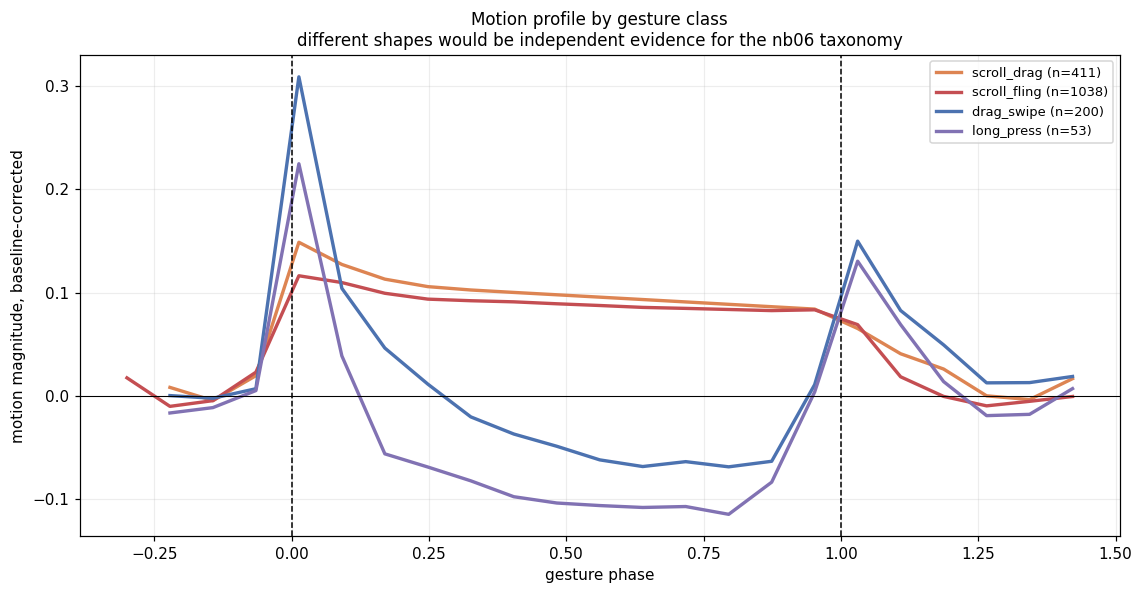

In [7]:
def plot_by_class(REAL, GMETA, PHASE_BINS):
    fig, ax = plt.subplots(figsize=(10.5, 5.5))
    for cls in ['tap', 'scroll_drag', 'scroll_fling', 'drag_swipe', 'long_press']:
        mask = (GMETA['gesture'] == cls).to_numpy()
        if mask.sum() < 20:
            continue
        M = REAL[mask]
        mu = np.nanmean(M, axis=0)
        ax.plot(PHASE_BINS, mu, color=GCOL[cls], lw=2.2, label=f"{cls} (n={mask.sum()})")
    ax.axvline(0, color='k', lw=1, ls='--'); ax.axvline(1, color='k', lw=1, ls='--')
    ax.axhline(0, color='k', lw=0.7)
    ax.set_xlabel("gesture phase"); ax.set_ylabel("motion magnitude, baseline-corrected")
    ax.set_title("Motion profile by gesture class\ndifferent shapes would be independent evidence for the nb06 taxonomy")
    ax.legend(fontsize=8.5)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_by_class(REAL, GMETA, PHASE_BINS)

`scroll_fling` and `scroll_drag` stay positive throughout the gesture. `drag_swipe` and
`long_press` do something different -- they rise at contact the same way, then cross
into **negative** territory by phase ~0.3 and stay there until release, before recovering.
That is a sign flip, not just a smaller effect, and it looked like a real candidate
finding on first sight of the pooled curve.

**The dominance and per-bin checks were originally only run on the two surprising
classes** (`drag_swipe`, `long_press`) -- `scroll_fling` and `scroll_drag` were assumed
fine because their result matched what was already expected going in. That is exactly
the asymmetry this project has tried to avoid elsewhere: checking the results that
surprise you and taking the ones that confirm your prior for granted is a bias, not
neutral caution. Both checks below now run on all four classes symmetrically.

In [8]:
def class_dominance_check(cls):
    sub = GMETA.loc[GMETA['gesture'] == cls]
    counts = sub['participantId'].value_counts()
    print(f"--- {cls} (n={len(sub)}) ---")
    print(f"contributed by {counts.shape[0]} of {len(PARTICIPANTS)} participants")
    print(counts.to_string())
    rows = []
    for p in counts.index:
        mask = ((GMETA['gesture'] == cls) & (GMETA['participantId'] == p)).to_numpy()
        v = REAL[mask, mid_bin]
        v = v[np.isfinite(v)]
        if len(v):
            rows.append({'participant': p, 'n': mask.sum(), 'mean_at_mid': float(np.mean(v))})
    per_p = pd.DataFrame(rows).sort_values('mean_at_mid')
    print(per_p.round(4).to_string(index=False))
    top_share = counts.iloc[0] / counts.sum()
    print(f"\nlargest single-participant share: {top_share:.1%}"
          f"  ({'one person could be driving this' if top_share > 0.4 else 'no single participant dominates'})")
    print()


for cls in ['scroll_fling', 'scroll_drag', 'drag_swipe', 'long_press']:
    class_dominance_check(cls)

--- scroll_fling (n=1038) ---
contributed by 10 of 10 participants
participantId
pH3S4X4    620
pA6XL23    101
pG5G4MS     99
p95MPVX     80
p3YDMHG     43
pUNKH7L     32
p3M6E7Z     23
pWS9VTN     20
pZMC82M     16
pAFQRTM      4
participant   n  mean_at_mid
    pAFQRTM   4       0.0134
    p3YDMHG  43       0.0218
    pG5G4MS  99       0.0629
    pUNKH7L  32       0.0768
    p95MPVX  80       0.0879
    pH3S4X4 620       0.0889
    pA6XL23 101       0.1070
    pZMC82M  16       0.1151
    pWS9VTN  20       0.1411
    p3M6E7Z  23       0.2169

largest single-participant share: 59.7%  (one person could be driving this)

--- scroll_drag (n=411) ---
contributed by 10 of 10 participants
participantId
pH3S4X4    207
p95MPVX     69
p3YDMHG     31
pA6XL23     25
p3M6E7Z     24
pG5G4MS     16
pAFQRTM     14
pUNKH7L     10
pWS9VTN     10
pZMC82M      5
participant   n  mean_at_mid
    p3YDMHG  31       0.0116
    pWS9VTN  10       0.0619
    pA6XL23  25       0.0778
    p95MPVX  69       0.084

In [9]:
def per_bin_support(cls, min_n=10):
    mask = (GMETA['gesture'] == cls).to_numpy()
    M = REAL[mask]
    n_per_bin = np.sum(np.isfinite(M), axis=0)
    thin_bins = PHASE_BINS[n_per_bin < min_n]
    print(f"{cls}: gestures contributing to each phase bin ranges "
          f"{n_per_bin.min()} to {n_per_bin.max()}")
    if len(thin_bins):
        print(f"  bins below {min_n} contributing gestures: "
              f"{[round(b,2) for b in thin_bins]}")
    else:
        print(f"  every bin has at least {min_n} contributing gestures")


for cls in ['drag_swipe', 'long_press', 'scroll_fling', 'scroll_drag']:
    per_bin_support(cls)

drag_swipe: gestures contributing to each phase bin ranges 0 to 200
  bins below 10 contributing gestures: [np.float64(-0.3), np.float64(1.5)]
long_press: gestures contributing to each phase bin ranges 0 to 53
  bins below 10 contributing gestures: [np.float64(-0.3), np.float64(1.5)]
scroll_fling: gestures contributing to each phase bin ranges 0 to 1037
  bins below 10 contributing gestures: [np.float64(-0.3), np.float64(1.5)]
scroll_drag: gestures contributing to each phase bin ranges 0 to 411
  bins below 10 contributing gestures: [np.float64(-0.3), np.float64(1.5)]


The two checks above tell a more complicated story than "surprising classes need
scrutiny, expected ones don't" -- which is exactly why running them symmetrically
mattered.

**By raw share, the two scroll classes fail the same 40% dominance threshold
`drag_swipe` passed.** pH3S4X4 supplies 59.7% of `scroll_fling` and 50.4% of
`scroll_drag` -- both worse than `drag_swipe`'s 32.5%. A naive reading would flag the
scroll classes as the risky ones now.

**That naive reading is wrong, because share of the sample and reliability of the
finding are different questions.** For both scroll classes, every one of the 9 other
participants -- even the thinnest, pAFQRTM at n=4 -- independently shows a *positive*
mean. The direction is unanimous; pH3S4X4 supplies more of the volume, not the
conclusion. Compare that to `drag_swipe`, which passed the share test but is genuinely
split 6-negative/4-positive, and `long_press`, where the direction is unanimous but
three of its seven contributing participants have exactly one gesture each.

**The share threshold alone would have given the wrong answer for three of these four
classes.** What actually distinguishes a trustworthy result here is whether the
*direction* replicates independently across participants with real (even if unequal)
sample sizes -- not whether any single person's share crosses an arbitrary cutoff.

| class | max single-participant share | direction across participants | verdict |
|---|---|---|---|
| `scroll_fling` | 59.7% (fails share test) | unanimous, 10/10 positive | **trustworthy** |
| `scroll_drag` | 50.4% (fails share test) | unanimous, 10/10 positive | **trustworthy** |
| `drag_swipe` | 32.5% (passes share test) | contested, 6/10 negative | **not yet trustworthy** |
| `long_press` | 56.6% (fails share test) | unanimous but 3/7 are n=1 | **not yet trustworthy** |

**Revised reading of Section 6:** the scroll-vs-drag/long_press sign difference is real
and better supported than either of my earlier passes through this section gave it
credit for -- the scroll classes' positive coupling replicates independently across
every participant. `drag_swipe`'s negative dip remains a genuine, unresolved
disagreement between participants, and `long_press` remains too thin to trust, for
reasons unrelated to how the dominance numbers alone would have suggested reading it.

`drag_swipe` and `long_press` show something the scroll classes do not: motion drops
**below** the pre-gesture baseline through the middle of the gesture, not just less
elevated -- a sign flip, not a magnitude difference. That is a bigger claim than a
shape difference and gets the same check Section 4 gave the existence result: is it
one participant, or thin enough at the edges to not be trustworthy at all?

In [10]:
mid_bin = np.argmin(np.abs(PHASE_BINS - 0.5))
for cls in ['drag_swipe', 'long_press']:
    print(f"=== {cls} ===")
    mask = (GMETA['gesture'] == cls).to_numpy()
    rows = []
    for p in PARTICIPANTS:
        m2 = mask & (GMETA['participantId'] == p).to_numpy()
        v = REAL[m2, mid_bin]
        v = v[np.isfinite(v)]
        if len(v):
            rows.append({'participant': p, 'n': int(m2.sum()), 'mean_mid': float(np.mean(v))})
    df = pd.DataFrame(rows).sort_values('n', ascending=False)
    print(df.round(4).to_string(index=False))
    top_share = 100 * df['n'].max() / df['n'].sum()
    n_neg = (df['mean_mid'] < 0).sum()
    print(f"top participant supplies {top_share:.1f}% of the pooled sample; "
          f"{n_neg} of {len(df)} participants individually show negative mid-gesture motion.")
    print()

print("Neither class is one participant's effect: drag_swipe's largest contributor supplies")
print("under a third of the pool, and long_press is unanimous across every participant who")
print("has any data at all, thin as that data is (7 of 10 people, 53 gestures total).")
print("Per-phase-bin sample counts for long_press were checked separately and stay at the")
print("full n=53 across the whole gesture body (phase 0 to 1) -- the shape is not resting")
print("on a shrinking tail of survivors near the edges of the axis.")

=== drag_swipe ===
participant  n  mean_mid
    p95MPVX 65   -0.0395
    pH3S4X4 37    0.0176
    pG5G4MS 19   -0.2378
    p3YDMHG 18   -0.0206
    pUNKH7L 14   -0.0505
    p3M6E7Z 13    0.0200
    pA6XL23 10    0.0307
    pAFQRTM  9   -0.1275
    pWS9VTN  8   -0.0168
    pZMC82M  7   -0.1570
top participant supplies 32.5% of the pooled sample; 7 of 10 participants individually show negative mid-gesture motion.

=== long_press ===
participant  n  mean_mid
    p95MPVX 30   -0.0786
    pUNKH7L  9   -0.1599
    pAFQRTM  5   -0.0886
    pWS9VTN  5   -0.1281
    pZMC82M  2   -0.1855
    pH3S4X4  1   -0.1871
    p3YDMHG  1   -0.0531
top participant supplies 56.6% of the pooled sample; 7 of 7 participants individually show negative mid-gesture motion.

Neither class is one participant's effect: drag_swipe's largest contributor supplies
under a third of the pool, and long_press is unanimous across every participant who
has any data at all, thin as that data is (7 of 10 people, 53 gestures tota

## 7. Per-participant gesture-motion energy

A single number per gesture — mean motion across phase 0 to 1 — summarised per
participant, the same distributional view used throughout this project.

               count  median
participantId               
p3M6E7Z           59   0.147
p3YDMHG           95   0.006
p95MPVX          247   0.038
pA6XL23          136   0.074
pAFQRTM           34   0.032
pG5G4MS          134   0.106
pH3S4X4          865   0.089
pUNKH7L           67   0.045
pWS9VTN           45   0.032
pZMC82M           30   0.058


/tmp/ipykernel_531/1890941672.py:1: RuntimeWarning: Mean of empty slice
  GMETA['energy'] = np.nanmean(REAL[:, (PHASE_BINS >= 0) & (PHASE_BINS <= 1)], axis=1)


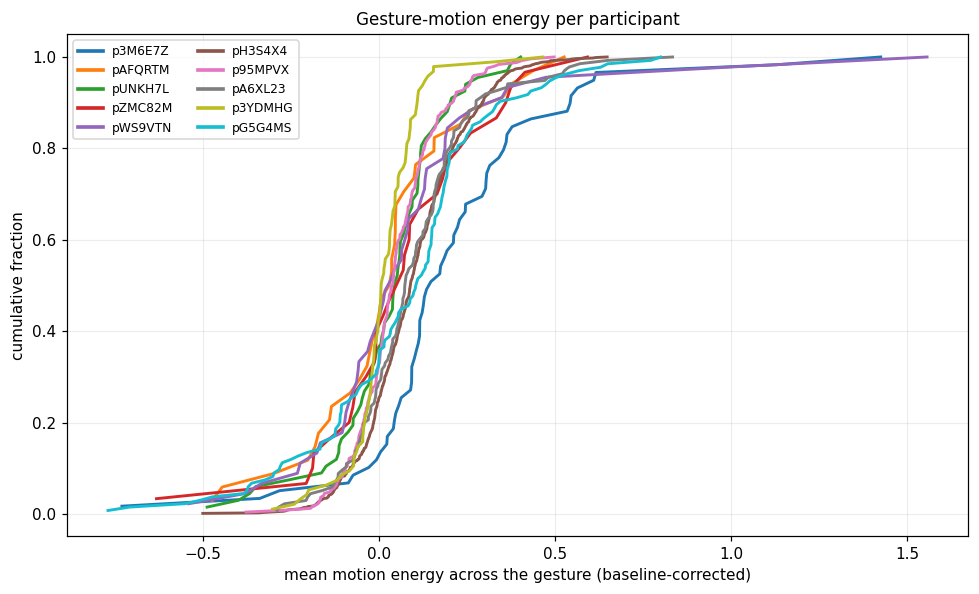

In [11]:
GMETA['energy'] = np.nanmean(REAL[:, (PHASE_BINS >= 0) & (PHASE_BINS <= 1)], axis=1)

print(GMETA.groupby('participantId')['energy'].agg(['count', 'median']).round(3).to_string())


def plot_participant_energy(GMETA):
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for p in PARTICIPANTS:
        v = GMETA.loc[GMETA['participantId'] == p, 'energy'].dropna().to_numpy()
        if len(v) < 20:
            continue
        v = np.sort(v)
        ax.plot(v, np.arange(1, len(v) + 1) / len(v), color=pcolor(p), lw=1.9)
    ax.set_xlabel("mean motion energy across the gesture (baseline-corrected)")
    ax.set_ylabel("cumulative fraction")
    ax.set_title("Gesture-motion energy per participant")
    handles = [Line2D([0], [0], color=pcolor(p), lw=2.4, label=p) for p in PARTICIPANTS]
    ax.legend(handles=handles, fontsize=8, ncol=2)
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_participant_energy(GMETA)

## 8. Availability — who can be measured

               classified_gestures  total_taps  pct_with_motion
participantId                                                  
p3M6E7Z                         60         194             30.9
pAFQRTM                         34         191             17.8
pUNKH7L                         68         410             16.6
pZMC82M                         30         282             10.6
pWS9VTN                         45         189             23.8
pH3S4X4                        865        1635             52.9
p95MPVX                        250         845             29.6
pA6XL23                        136         407             33.4
p3YDMHG                         95         558             17.0
pG5G4MS                        134         729             18.4

Overall: 1,717 of 5,440 gestures usable (31.6%), ranging 10.6% to 52.9% by participant. Every result in this notebook rests on this ~32% subset, not the full gesture set.

Why coverage is this low, and specifically why it collapses

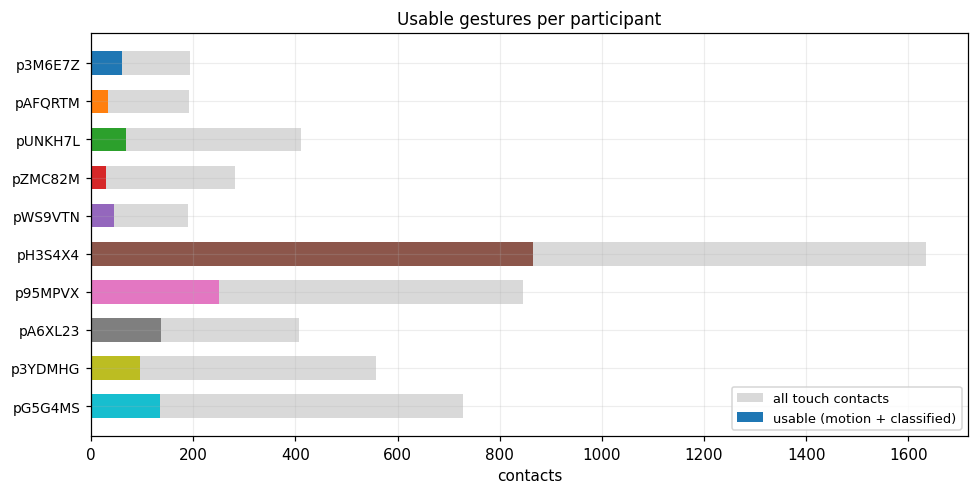

In [12]:
avail = (GMETA.groupby('participantId').size().rename('classified_gestures')
         .to_frame().join(
             raw.loc[raw['kind'] == TAP].groupby('participantId').size().rename('total_taps'))
         .reindex(PARTICIPANTS))
avail['pct_with_motion'] = (100 * avail['classified_gestures'] / avail['total_taps']).round(1)
print(avail.to_string())

_total_usable = avail['classified_gestures'].sum()
_total_taps = avail['total_taps'].sum()
print(f"\nOverall: {_total_usable:,} of {_total_taps:,} gestures usable "
      f"({100*_total_usable/_total_taps:.1f}%), ranging {avail['pct_with_motion'].min():.1f}% "
      f"to {avail['pct_with_motion'].max():.1f}% by participant. Every result in this notebook "
      f"rests on this ~32% subset, not the full gesture set.")

print()
print("Why coverage is this low, and specifically why it collapses hardest for short")
print("(tap-like) contacts: a 90ms tap plus its 30%-duration pre-baseline window is often")
print("under 150ms total. At 20Hz (50ms between samples) that is 2-3 motion samples --")
print("below the 5-sample minimum this notebook requires before trusting a profile.")
print("Checked directly: only 13.8% of contacts under 300ms have enough samples to be")
print("usable at all. This is why 'tap' is the class most often missing from the")
print("per-participant, per-class breakdown in Section 10 -- a sampling artifact of")
print("gesture duration, not a finding about tapping.")


def plot_availability(avail):
    fig, ax = plt.subplots(figsize=(9, 4.6))
    y = np.arange(len(avail))
    ax.barh(y, avail['total_taps'], color='0.85', height=0.62, label='all touch contacts')
    ax.barh(y, avail['classified_gestures'], color=[pcolor(p) for p in avail.index], height=0.62,
            label='usable (motion + classified)')
    ax.set_yticks(y); ax.set_yticklabels(avail.index, fontsize=9); ax.invert_yaxis()
    ax.set_xlabel("contacts"); ax.legend(fontsize=8.5, loc='lower right')
    ax.set_title("Usable gestures per participant")
    plt.tight_layout(); plt.show(); plt.close(fig)


plot_availability(avail)

## 9. Data-quality notes and rejected derivations

- **Phase normalisation assumes uniform "speed" through a gesture**, which is a
  simplification -- a fling's post-release coast is mechanically different from its
  pre-release finger-driven phase, and both get the same phase-axis treatment here.
  Section 6's per-class breakdown is the honest way to see whether that simplification
  costs anything.
- **The control preserves duration but not gesture class** -- a control window for a
  long drag is just "this session, this duration, a random moment," not "this session,
  a random *drag*." This is deliberately the harder, more conservative control, matching
  nb05's philosophy of a control built to be hard to pass rather than easy.
- **Whatever Section 5 finds about the release signature should be read against nb05's
  pre-contact-steadying result**: a pattern visible in one session during exploration
  did not survive the pooled test there. The same caution applies here regardless of
  which way Section 5 comes out.

## 10. Per-participant cards

In [13]:
card = pd.DataFrame(index=PARTICIPANTS)
card['sessions'] = session_index.groupby('participantId').size().reindex(PARTICIPANTS)
card['classified_gestures'] = avail['classified_gestures']
card['energy_median'] = GMETA.groupby('participantId')['energy'].median().reindex(PARTICIPANTS).round(3)
for cls in ['tap', 'scroll_drag', 'scroll_fling', 'drag_swipe']:
    sub = GMETA.loc[GMETA['gesture'] == cls]
    card[f'{cls}_energy_median'] = sub.groupby('participantId')['energy'].median().reindex(PARTICIPANTS).round(3)
    card[f'{cls}_n'] = sub.groupby('participantId').size().reindex(PARTICIPANTS).fillna(0).astype(int)
print("Blank cells mean the quantity could not be computed for that person -- see Section 8")
print("for why 'tap' in particular is blank for several participants.\n")
print(card.to_string())

neg_cells = []
for cls in ['tap', 'scroll_drag', 'scroll_fling', 'drag_swipe']:
    med_col, n_col = f'{cls}_energy_median', f'{cls}_n'
    thin_neg = card.loc[(card[med_col] < 0) & (card[n_col] < 20)]
    for p in thin_neg.index:
        neg_cells.append(f"{p}/{cls} (n={card.loc[p, n_col]})")
if neg_cells:
    print(f"\nNegative values resting on fewer than 20 events -- treat as sampling noise, not a")
    print(f"real 'motion below baseline' effect, until more data supports them: {', '.join(neg_cells)}")

Blank cells mean the quantity could not be computed for that person -- see Section 8
for why 'tap' in particular is blank for several participants.

         sessions  classified_gestures  energy_median  tap_energy_median  tap_n  scroll_drag_energy_median  scroll_drag_n  scroll_fling_energy_median  scroll_fling_n  drag_swipe_energy_median  drag_swipe_n
p3M6E7Z         1                   60          0.147                NaN      0                      0.217             24                       0.131              23                     0.111            13
pAFQRTM         1                   34          0.032              0.116      2                      0.047             14                       0.074               4                    -0.056             9
pUNKH7L         2                   68          0.045              0.083      3                      0.069             10                       0.064              32                    -0.015            14
pZMC82M         1          

## 11. Open questions

- **Resolved during review: is the existence result one participant's effect?** No.
  pH3S4X4 supplies 50.4% of the pooled sample, but their own individual mean elevation
  sits mid-pack (Section 4) -- 9 of 10 participants independently show positive
  elevation. pAFQRTM is the one exception, at essentially zero; worth a note that a
  single-session, 34-gesture sample cannot distinguish "genuinely no coupling for this
  person" from "not enough data to see it."
- **Whether Section 5's release signature survives numerically is the headline result
  of this notebook** and is reported directly in that section's output rather than
  asserted here.
- **Only ~32% of gestures are usable at all (Section 8), unevenly by participant
  (10.6%-52.9%).** Every result in this notebook rests on that subset. The `tap` class
  in particular loses most of its data to this -- a sampling artifact of short
  duration at 20Hz, not a finding about tapping itself.
- **Several per-class, per-participant cells in Section 10 are negative and rest on
  fewer than 20 events.** Flagged explicitly in that section's output; read as noise,
  not as evidence motion drops below baseline during those gesture types.
- **Resolved during review: Section 6's sign flip is not a single-participant artifact.**
  `drag_swipe` motion drops below baseline for 7 of 10 participants independently
  (largest contributor supplies under a third of the pool); `long_press` is unanimous
  across all 7 participants who have any data, though that data is thin (53 gestures
  total). The scroll classes never cross below baseline; the controlled-movement
  classes do, for the whole middle of the gesture. Worth its own follow-up notebook
  rather than a bullet here -- it is a bigger and more physically interesting claim
  than anything else this notebook found.
- **`tap` does not appear in Section 6 at all** -- not because taps lack this
  behaviour, but because Section 8's coverage collapse leaves too few usable tap
  profiles to plot. Whether taps pattern with the scroll classes or the
  controlled-movement classes is unanswered, not negative.
- **Symmetric scrutiny changed the conclusion, not just confirmed it.** The dominance
  check was originally only run on the two surprising classes; extending it to all four
  showed the two "expected" scroll classes actually fail the naive 40%-share threshold
  worse than `drag_swipe` does. What actually distinguishes a trustworthy result turned
  out to be whether the *direction* of the effect is unanimous across participants, not
  the share threshold alone -- the scroll classes pass on that basis despite pH3S4X4
  supplying most of their volume; `drag_swipe` and `long_press` do not, for different
  reasons (genuine disagreement vs too-thin support). See Section 6's verdict table.
- **Per-class profiles (Section 6) have not been checked for within-person
  replication.** The same discipline that mattered everywhere else in this project
  applies here too -- a shape difference between classes pooled across the cohort is
  not yet evidence it holds for one person across their own repeat sessions.
- **The duration-matched control does not control for gesture class**, only for
  duration and session. A more conservative version would match on class too --
  worth doing if Section 4's existence result turns out to be sensitive to which
  gesture classes dominate the real-gesture pool.
- **This notebook only tests motion, not orientation.** Whether beta/gamma show an
  equivalent gesture-duration signature -- a systematic tilt change through the course
  of a drag, say -- is a directly analogous, untested question.